In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from datetime import datetime

In [60]:
df = pd.read_csv("pendulum_trajectories.csv")

In [61]:
df["theta"] = (df["theta"] + np.pi) % (2 * np.pi) - np.pi
df["theta_next"] = (df["theta_next"] + np.pi) % (2 * np.pi) - np.pi

In [62]:
train = df[df["split"] == "train"]

In [63]:
class SimDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx, :], self.y[idx, :]
    
dataset = SimDataset(train[["theta", "omega"]].values, train[["theta_next", "omega_next"]].values)

loader = DataLoader(dataset, batch_size=32)

In [3]:
class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        return self.mlp(x)

In [65]:
dt = 0.01
g = 9.81
L = 1.0
lambda_ = 0.01 # residual weight
beta_ = 1 # theta weight
delta_ = 0.05 # omega weight

def loss_fn(x, y, y_hat):
    theta_loss = nn.functional.mse_loss(y_hat[:, 0], y[:, 0])
    omega_loss = nn.functional.mse_loss(y_hat[:, 1], y[:, 1])
    
    
    alpha_hat = (y_hat[:, 1] - x[:, 1]) / dt
    alpha_expected = -(g / L) * torch.sin(x[:, 0])
    
    physics_loss = nn.functional.mse_loss(alpha_hat, alpha_expected)
    
    return (beta_ * theta_loss) + (delta_ * omega_loss) + (lambda_ * physics_loss), theta_loss, omega_loss, physics_loss

In [4]:
hidden_dim = 16
model = PINN(2, hidden_dim, 2)

In [ ]:
lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [67]:
epochs = 200

for epoch in range(epochs):
    total_loss = 0
    total_theta = 0
    total_omega = 0
    total_phys = 0
    for x, y in loader:
        optimizer.zero_grad()

        x = x.to(torch.float32)
        y = y.to(torch.float32)

        y_hat = model(x)

        loss, theta_loss, omega_loss, phys_loss = loss_fn(x, y, y_hat)
        total_loss += loss.item()
        total_theta += theta_loss.item()
        total_omega += omega_loss.item()
        total_phys += phys_loss.item()

        loss.backward()
        optimizer.step()
    print(
        f"Epoch: {epoch+1} | Loss: {total_loss / len(loader):.2f} | Theta: {total_theta / len(loader):.2f} | Omega: {total_omega / len(loader):.2f} | Physics: {total_phys / len(loader):.2f}"
    )

Epoch: 1 | Loss: 277.05 | Theta: 2.66 | Omega: 2.74 | Physics: 27425.44
Epoch: 2 | Loss: 64.13 | Theta: 2.00 | Omega: 0.62 | Physics: 6209.60
Epoch: 3 | Loss: 38.20 | Theta: 1.22 | Omega: 0.37 | Physics: 3695.79
Epoch: 4 | Loss: 24.44 | Theta: 0.67 | Omega: 0.24 | Physics: 2375.73
Epoch: 5 | Loss: 16.36 | Theta: 0.40 | Omega: 0.16 | Physics: 1595.12
Epoch: 6 | Loss: 11.25 | Theta: 0.27 | Omega: 0.11 | Physics: 1097.55
Epoch: 7 | Loss: 7.94 | Theta: 0.20 | Omega: 0.08 | Physics: 773.64
Epoch: 8 | Loss: 5.79 | Theta: 0.16 | Omega: 0.06 | Physics: 562.91
Epoch: 9 | Loss: 4.39 | Theta: 0.13 | Omega: 0.04 | Physics: 425.90
Epoch: 10 | Loss: 3.47 | Theta: 0.11 | Omega: 0.03 | Physics: 335.83
Epoch: 11 | Loss: 2.85 | Theta: 0.10 | Omega: 0.03 | Physics: 275.15
Epoch: 12 | Loss: 2.42 | Theta: 0.08 | Omega: 0.02 | Physics: 232.92
Epoch: 13 | Loss: 2.10 | Theta: 0.08 | Omega: 0.02 | Physics: 202.43
Epoch: 14 | Loss: 1.87 | Theta: 0.07 | Omega: 0.02 | Physics: 179.48
Epoch: 15 | Loss: 1.68 | Thet

In [5]:
weights = torch.load("pinn_models/pinn-05-11-12:26:22-16hdim.pth")
model.load_state_dict(weights)

<All keys matched successfully>

In [69]:
model.eval()
test = df[df["split"] == "test"]

x_test = torch.tensor(test[["theta", "omega"]].values, dtype=torch.float32)
y_test = torch.tensor(test[["theta_next", "omega_next"]].values, dtype=torch.float32)

with torch.no_grad():
    y_pred = model(x_test)
    test_loss = nn.functional.mse_loss(y_pred, y_test)

print(f"Test MSE: {test_loss.item():.6f}")

# Per-component breakdown so you can see if theta or omega is harder to predict
theta_mse = nn.functional.mse_loss(y_pred[:, 0], y_test[:, 0])
omega_mse = nn.functional.mse_loss(y_pred[:, 1], y_test[:, 1])
print(f"Theta MSE: {theta_mse.item():.6f} | Omega MSE: {omega_mse.item():.6f}")

Test MSE: 0.009696
Theta MSE: 0.009772 | Omega MSE: 0.009621


In [6]:
theta0 = np.pi/4  # radians
omega0 = 0.0  # rad/s
n_steps = 1000

rows = []
state = torch.tensor([[theta0, omega0]], dtype=torch.float32)

model.eval()
with torch.no_grad():
    for _ in range(n_steps):
        next_state = model(state)

        theta_next = (next_state[0, 0].item() + np.pi) % (2 * np.pi) - np.pi
        omega_next = next_state[0, 1].item()

        rows.append([theta_next, omega_next])
        state = torch.tensor([[theta_next, omega_next]], dtype=torch.float32)

arr = np.array(rows)  # shape (N, 2) — [theta, omega] per row
np.save("pinn_trajectory.npy", arr)
print(f"Saved {len(arr)} steps to pinn_trajectory.npy")

Saved 1000 steps to pinn_trajectory.npy


In [71]:
now = datetime.now()
date_time = now.strftime("%m-%d-%H:%M:%S")

torch.save(model.state_dict(), f"pinn_models/pinn-{date_time}-{hidden_dim}hdim.pth")

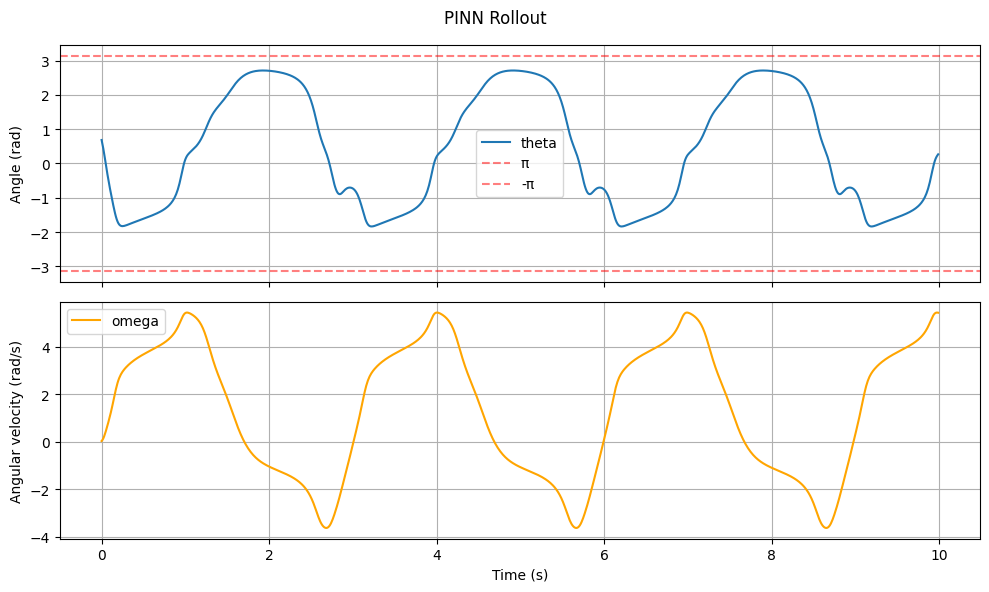

In [7]:
import numpy as np
import matplotlib.pyplot as plt

arr = np.load("pinn_trajectory.npy")
t = np.arange(len(arr)) * 0.01  # timestep = 0.01

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(t, arr[:, 0], label="theta")
ax1.set_ylabel("Angle (rad)")
ax1.axhline(np.pi, color="r", linestyle="--", alpha=0.5, label="π")
ax1.axhline(-np.pi, color="r", linestyle="--", alpha=0.5, label="-π")
ax1.legend()
ax1.grid(True)

ax2.plot(t, arr[:, 1], label="omega", color="orange")
ax2.set_ylabel("Angular velocity (rad/s)")
ax2.set_xlabel("Time (s)")
ax2.legend()
ax2.grid(True)

plt.suptitle("PINN Rollout")
plt.tight_layout()
plt.show()